<a href="https://colab.research.google.com/github/MohitVerma0098/6thSem-ML-Lab/blob/main/ML_LAB_EXAM_1BM23CS198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  🔵 K-MEANS CLUSTERING & EXPLORATION
Enter CSV path (default: data.csv): /mnt/Mall_Customers.csv
Drop any column? (leave blank to skip): 
✅ Loaded: 200 rows × 5 columns

  🔵 Handling Missing Values:
    No missing values in 'CustomerID'.
    No missing values in 'Gender'.
    No missing values in 'Age'.
    No missing values in 'Annual Income (k$)'.
    No missing values in 'Spending Score (1-100)'.

  🔵 Descriptive Statistics (Outlier Hinting):
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000  

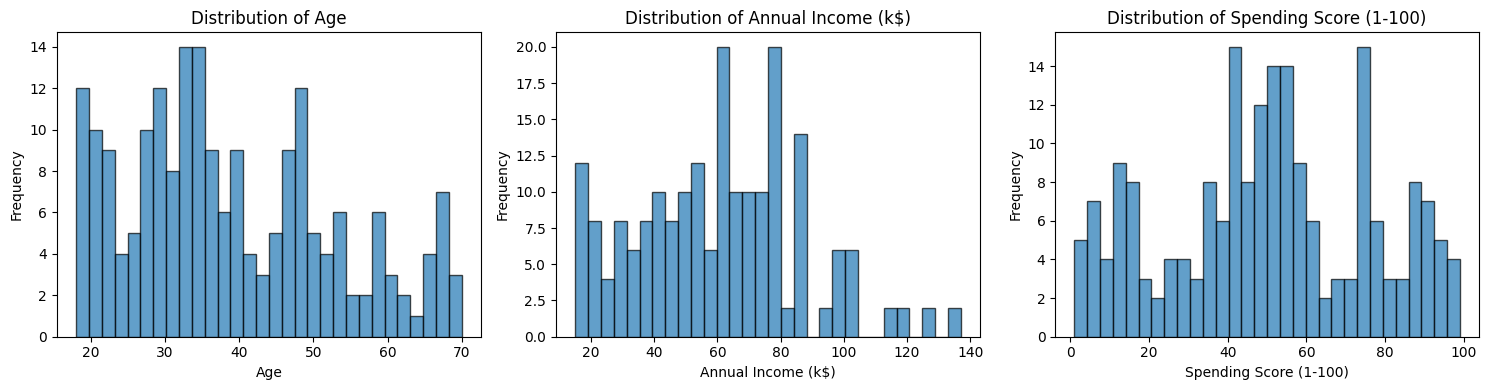


  Specify Features for K-Means Clustering
Available features: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)
Enter comma-separated column names to use for clustering (e.g., 'Annual Income (k$)', 'Income, Spending Score (1-100)'): Age,Annual Income
Proceeding with clustering using selected features: Age

  🔵 K-MEANS CLUSTERING EXECUTION
Enter number of clusters K (default 3): 2

  🔵 K-Means Clustering Results
  Clusters         : 2
  Inertia (WCSS)   : 54.3357
  Silhouette Score : 0.6321
  Visualizing clusters for single feature: 'Age'


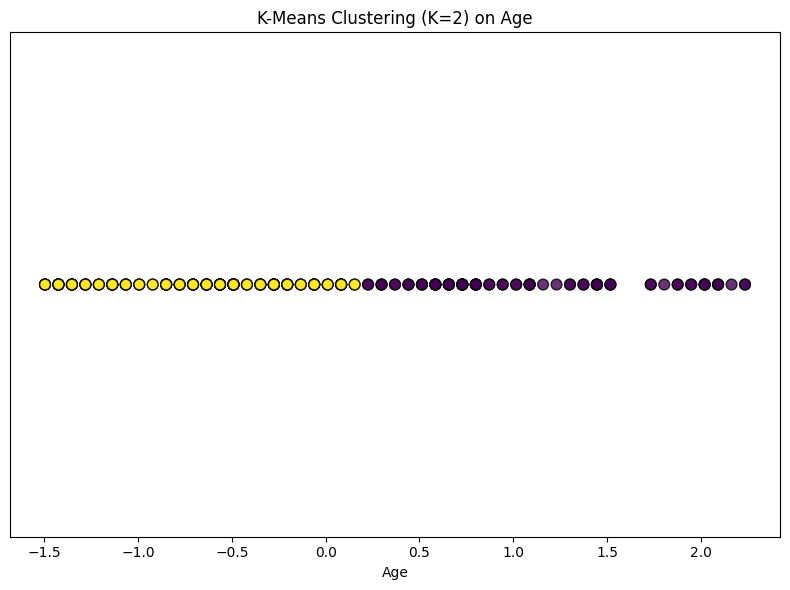


  📊 CLUSTER CHARACTERISTICS (K=2)


TypeError: agg function failed [how->mean,dtype->object]

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier # New import
from sklearn.model_selection import train_test_split # New import
from sklearn.metrics import classification_report, accuracy_score # New import


def plot_distributions(df, columns):
    """Plots histograms for specified numerical columns in a DataFrame."""
    n_cols = len(columns)
    if n_cols == 0:
        return

    # Determine grid size (up to 3 columns per row)
    n_rows = (n_cols + 2) // 3 if n_cols > 0 else 0
    if n_rows == 0: return

    fig, axes = plt.subplots(n_rows, min(n_cols, 3), figsize=(5 * min(n_cols, 3), 4 * n_rows))
    # Ensure axes is always an array for consistent indexing
    if n_rows == 1 and min(n_cols, 3) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(columns):
        if i < len(axes):
            ax = axes[i]
            if pd.api.types.is_numeric_dtype(df[col]):
                ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
                ax.set_title(f'Distribution of {col}')
                ax.set_xlabel(col)
                ax.set_ylabel('Frequency')
            else:
                # For categorical (object) types, plot value counts
                top_n = df[col].value_counts().nlargest(10) # Show top 10 categories
                if not top_n.empty:
                    ax.bar(top_n.index.astype(str), top_n.values, edgecolor='black', alpha=0.7)
                    ax.set_title(f'Distribution of {col} (Top {len(top_n)})')
                    ax.set_xlabel(col)
                    ax.set_ylabel('Count')
                    ax.tick_params(axis='x', rotation=45)
                else:
                    ax.set_title(f'No data to plot for {col}')
                    ax.axis('off') # Turn off axis if no data

    # Remove any unused subplots
    for i in range(n_cols, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

def load_and_preprocess_unsupervised(path, drop_col=None):
    """Load and preprocess for unsupervised learning (no target)."""
    df = pd.read_csv(path)
    print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

    if drop_col and drop_col in df.columns:
        df = df.drop(columns=[drop_col])
        print(f"  Dropped column: '{drop_col}'")

    print("\n  🔵 Handling Missing Values:")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                fill_value = df[col].mean()
                df[col].fillna(fill_value, inplace=True)
                print(f"    Filled missing values in '{col}' with mean: {fill_value:.2f}")
            else:
                fill_value = df[col].mode()[0]
                df[col].fillna(fill_value, inplace=True)
                print(f"    Filled missing values in '{col}' with mode: '{fill_value}'")
        else:
            print(f"    No missing values in '{col}'.")

    # Outlier Hinting
    print("\n  🔵 Descriptive Statistics (Outlier Hinting):")
    print(df.describe())
    print("\n  Consider analyzing min/max values and standard deviations for potential outliers.")

    # Store original column names for distribution plots later, before encoding, but after missing value imputation
    preprocessed_df_for_plots = df.copy()

    print("\n  🔵 Encoding Categorical Features:")
    for col in df.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"    Encoded '{col}'")

    features = list(df.columns)
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(df), columns=features)
    print(f"\n  Scaled {len(features)} features for clustering.")
    return X, features, preprocessed_df_for_plots # Return preprocessed_df_for_plots for visualization

def run():
    print("\n" + "=" * 60)
    print("  🔵 K-MEANS CLUSTERING & EXPLORATION")
    print("=" * 60)

    path = input("Enter CSV path (default: data.csv): ").strip() or "data.csv"
    drop = input("Drop any column? (leave blank to skip): ").strip()

    X_all_features, all_features_names, preprocessed_df_for_plots = load_and_preprocess_unsupervised(path, drop if drop else None)

    # Visualize Distributions after preprocessing but before scaling (for readability)
    print("\n" + "=" * 60)
    print("  📊 FEATURE DISTRIBUTIONS")
    print("=" * 60)
    dist_cols_candidates = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income'] # Add 'Income' as an alternative
    dist_cols = [col for col in dist_cols_candidates if col in preprocessed_df_for_plots.columns]
    if not dist_cols:
        print("  Could not find common columns for distribution plots (e.g., 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income').")
        print("  Please adjust 'dist_cols_candidates' in the code or ensure your dataset contains these columns.")
    else:
        plot_distributions(preprocessed_df_for_plots, dist_cols)


    # User specifies features for clustering
    print("\n" + "=" * 60)
    print("  Specify Features for K-Means Clustering")
    print("=" * 60)
    print(f"Available features: {', '.join(all_features_names)}")
    cluster_cols_input = input("Enter comma-separated column names to use for clustering (e.g., 'Annual Income (k$)', 'Income, Spending Score (1-100)'): ").strip()

    if not cluster_cols_input:
        print("No specific columns provided for clustering. Clustering will proceed with ALL features.")
        X_for_clustering = X_all_features
        features_for_clustering = all_features_names
    else:
        requested_cols = [col.strip() for col in cluster_cols_input.split(',')]
        features_for_clustering = [col for col in requested_cols if col in all_features_names]
        if not features_for_clustering:
            print(f"Warning: None of the requested columns '{cluster_cols_input}' found in the dataset. Clustering will proceed with ALL features.")
            X_for_clustering = X_all_features
            features_for_clustering = all_features_names
        else:
            print(f"Proceeding with clustering using selected features: {', '.join(features_for_clustering)}")
            X_for_clustering = X_all_features[features_for_clustering]

    # K-Means clustering starts here
    print("\n" + "=" * 60)
    print("  🔵 K-MEANS CLUSTERING EXECUTION")
    print("=" * 60)

    k = input("Enter number of clusters K (default 3): ").strip()
    k = int(k) if k else 3

    # Train K-Means
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_for_clustering) # Use X_for_clustering here

    labels = model.labels_
    inertia = model.inertia_

    # Evaluate — Clustering Metrics
    print(f"\n{'=' * 50}")
    print(f"  🔵 K-Means Clustering Results")
    print(f"{'=' * 50}")
    print(f"  Clusters         : {k}")
    print(f"  Inertia (WCSS)   : {inertia:.4f}")
    if k > 1:
        sil = silhouette_score(X_for_clustering, labels) # Use X_for_clustering here
        print(f"  Silhouette Score : {sil:.4f}")
    print(f"{'=' * 50}")

    # Visualization — 2D Cluster Plot
    plt.figure(figsize=(8, 6))

    # Handle plotting based on number of features used for clustering
    if len(features_for_clustering) == 1:
        # For a single feature, a 1D scatter plot or histogram with colors
        print(f"  Visualizing clusters for single feature: '{features_for_clustering[0]}'")
        plt.scatter(X_for_clustering.iloc[:, 0], np.zeros_like(X_for_clustering.iloc[:, 0]), c=labels, cmap='viridis', edgecolors='k', s=60, alpha=0.8)
        plt.yticks([]) # Hide y-axis ticks for 1D plot
        plt.xlabel(features_for_clustering[0])
        plt.title(f'K-Means Clustering (K={k}) on {features_for_clustering[0]}')

    elif len(features_for_clustering) >= 2:
        # Use the first two selected features for 2D plot
        X_arr = np.array(X_for_clustering)
        scatter = plt.scatter(X_arr[:, 0], X_arr[:, 1], c=labels, cmap='viridis',
                              edgecolors='k', s=60, alpha=0.8)
        centers = model.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X',
                    s=200, edgecolors='k', linewidths=2, label='Centroids')
        plt.xlabel(features_for_clustering[0])
        plt.ylabel(features_for_clustering[1])
        plt.title(f'K-Means Clustering (K={k}) on {features_for_clustering[0]} and {features_for_clustering[1]}')
        plt.colorbar(scatter, label='Cluster')
        plt.legend()
    else:
        print("  Not enough features selected for a 2D cluster visualization.")

    plt.tight_layout()
    plt.show()

    # Optional: Display cluster characteristics (mean values of features per cluster)
    print("\n" + "=" * 60)
    print(f"  📊 CLUSTER CHARACTERISTICS (K={k})")
    print("=" * 60)
    preprocessed_df_with_clusters = preprocessed_df_for_plots.copy()
    preprocessed_df_with_clusters['Cluster'] = labels
    # Now, group by 'Cluster' and show mean values for ALL original features
    print(preprocessed_df_with_clusters.groupby('Cluster')[all_features_names].mean())
    print("\n  These are the mean values of ALL original features for each cluster, providing insights into cluster profiles derived from the specified features.")

    # Random Forest Comparison (uses all original features to predict the clusters)
    print("\n" + "=" * 60)
    print("  🌳 RANDOM FOREST CLASSIFIER ON CLUSTERS")
    print("=" * 60)

    # Use all original features (X_all_features) to predict the K-Means labels
    if len(all_features_names) > 1: # Ensure there's more than just the target for prediction
        X_train, X_test, y_train, y_test = train_test_split(X_all_features, labels, test_size=0.3, random_state=42) # Removed stratify=labels

        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        y_pred = rf_model.predict(X_test)

        print(f"\n{'=' * 50}")
        print(f"  🔵 Random Forest Performance Predicting K-Means Clusters")
        print(f"{'=' * 50}")
        print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        print(f"{'=' * 50}")

        # Feature Importance
        print("\n  Feature Importances for Predicting Clusters:")
        feature_importances = pd.Series(rf_model.feature_importances_, index=all_features_names).sort_values(ascending=False)
        print(feature_importances)
        print("\n  This shows which original features were most influential in predicting the clusters created by K-Means.")
    else:
        print("  Random Forest comparison skipped: Not enough features in the dataset to perform a meaningful classification task.")


if __name__ == "__main__":
    run()